# Real data analysis project in `duckdb`

In this notebook, we will analyze a big dataset which would be
problematic in pure Python.

We want to take a look at the [arXiv](https://arxiv.org) data. arXiv is (one of the)
biggest library of preprint papers which is available on the 
Internet. Assembling the data would be complicated (and interesting),
but this has already been done by the Cornell University. The
resulting dataset is published on [Kaggle](https://www.kaggle.com/datasets/Cornell-University/arxiv).

You will see that the dataset has certain *challenges* like nested fields,
time and date in different formats and string fields which acutally contain
lists. Moreover, the dataset is quite large. Therefore, a ZIP file with
JSON data is provided in Kaggle.

## Setup

This is again just the prologue to allow the notebooks running standalone in a local Jupyter installation and in Google Colab.

In [1]:
import os
try:
    import google.colab
    IN_COLAB = True
    if not os.path.isdir("/content/oreilly-duckdb"):
        os.system("git clone https://github.com/datanizing/oreilly-duckdb")
    os.system("pip install -U duckdb")
    data = "/content/oreilly-duckdb/data"
except:
    IN_COLAB = False
    data = "data"

## Download data

The data with all arXiv abstracts is available on [Kaggle](https://www.kaggle.com/datasets/Cornell-University/arxiv).
Fortunately, it is also possible to download the dataset without logging into Kaggle.

As download can take a while depending on the speed of your Internet connection,
the download is organized in chunks which allow a progress display:

In [ ]:
from tqdm.auto import tqdm
import requests

response = requests.get("https://www.kaggle.com/api/v1/datasets/download/Cornell-University/arxiv", stream=True)
total_size = int(response.headers.get("content-length", 0))
block_size = 1024

with tqdm(total=total_size, unit="B", unit_scale=True) as progress_bar:
    with open("arxiv.zip", "wb") as file:
        for data in response.iter_content(block_size):
            progress_bar.update(len(data))
            file.write(data)

if total_size != 0 and progress_bar.n != total_size:
    print("Could not download file")

As explained above, the data is provided in `ZIP` format.
To avoid unpacking, we can use the `zipfs` extension in 
`duckdb` and access the data in the `ZIP` file directly.

The extension needs to be installed first, then it can be
loaded. Even if you have installed it before, it does not
hurt to reinstall (and it is necessary if you use Google
Colab and have a new session):

## Ingest data

In [2]:
import duckdb
duckdb.sql("INSTALL zipfs FROM community; LOAD zipfs") 

If the extension does not work for you, you can 
extract he files manually or use the following code
to extract the files (adjust the names in following the `duckdb`
statements appropriately):
```python
from zipfile import ZipFile
with ZipFile("arxiv.zip", 'r') as zip_ref:
    zip_ref.extractall(".")
```

First convert the data to `parquet` format so we have fast access. We will use
the current timestamp in the converted `parquet` file. There are a 
few reasons for that:
* New versions of `arxiv.zip` become available every few days.
* We don't want to overwrite an already existing converted `parquet` file.
* If we use more sophisticated analysis (like NLP or LLMs) on the data, we
  would like to restrict that on the new data (incremental updates). 

In [3]:
from datetime import datetime
today = datetime.now().strftime('%Y%m%d')
today

'20260908'

Great, now we have a timestamp and can convert the data.

Converting the data to `parquet` format in the first step might
look a bit *exaggerated*, but as it is so much faster to access
the data, it is often a good idea. That's especially true for
data in `ZIP` files, as it needs to be extracted first.

Therefore, let's convert the data to a timestamped `parquet` file:

In [4]:
%%time
# remove the zip://arxiv.zip/ if you unpacked the file above:
duckdb.sql(f"COPY (SELECT * FROM 'zip://arxiv.zip/arxiv-metadata-oai-snapshot.json') TO 'arxiv-{today}.parquet'")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CPU times: user 1min 31s, sys: 12.7 s, total: 1min 44s
Wall time: 37.4 s


This takes considerable time, especially if disks are slow (or on Colab).
Depending on your CPU configuration, you will see that `duckdb` is
inherently multi-threaded.

After the conversion, we can take a look at the data (sounds counter-intuitive,
but the conversion does not lose any data). First check the number of articles:

## General Structure and Volume

In [5]:
duckdb.sql(f"SELECT count(*) FROM 'arxiv-{today}.parquet'").pl()

count_star()
i64
3156800


Wow, that's really many articles. A `DataFrame` with so many articles would
be possible to handle in Python, but that depends heavily on the column
structure. 

As the `parquet` file is stored in columnar format, selecting all rows is
very expensive. For the following statements, we use a restriction of five
rows to keep the statements fast.

Let's check the structure:

In [6]:
duckdb.sql(f"FROM 'arxiv-{today}.parquet' LIMIT 5").pl()

id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
str,str,str,str,str,str,str,str,str,str,str,list[struct[2]],date,list[list[str]]
"""0704.0001""","""Pavel Nadolsky""","""C. Bal\'azs, E. L. Berger, P. …","""Calculation of prompt diphoton…","""37 pages, 15 figures; publishe…","""Phys.Rev.D76:013009,2007""","""10.1103/PhysRevD.76.013009""","""ANL-HEP-PR-07-12""","""hep-ph""",null,""" A fully differential calcula…","[{""v1"",""Mon, 2 Apr 2007 19:18:42 GMT""}, {""v2"",""Tue, 24 Jul 2007 20:10:27 GMT""}]",2008-11-26,"[[""Balázs"", ""C."", """"], [""Berger"", ""E. L."", """"], … [""Yuan"", ""C. -P."", """"]]"
"""0704.0002""","""Louis Theran""","""Ileana Streinu and Louis Thera…","""Sparsity-certifying Graph Deco…","""To appear in Graphs and Combin…",null,null,null,"""math.CO cs.CG""","""http://arxiv.org/licenses/none…",""" We describe a new algorithm,…","[{""v1"",""Sat, 31 Mar 2007 02:26:18 GMT""}, {""v2"",""Sat, 13 Dec 2008 17:26:00 GMT""}]",2008-12-13,"[[""Streinu"", ""Ileana"", """"], [""Theran"", ""Louis"", """"]]"
"""0704.0003""","""Hongjun Pan""","""Hongjun Pan""","""The evolution of the Earth-Moo…","""23 pages, 3 figures""",null,null,null,"""physics.gen-ph""",null,""" The evolution of Earth-Moon …","[{""v1"",""Sun, 1 Apr 2007 20:46:54 GMT""}, {""v2"",""Sat, 8 Dec 2007 23:47:24 GMT""}, {""v3"",""Sun, 13 Jan 2008 00:36:28 GMT""}]",2008-01-13,"[[""Pan"", ""Hongjun"", """"]]"
"""0704.0004""","""David Callan""","""David Callan""","""A determinant of Stirling cycl…","""11 pages""",null,null,null,"""math.CO""",null,""" We show that a determinant o…","[{""v1"",""Sat, 31 Mar 2007 03:16:14 GMT""}]",2007-05-23,"[[""Callan"", ""David"", """"]]"
"""0704.0005""","""Alberto Torchinsky""","""Wael Abu-Shammala and Alberto …","""From dyadic $\Lambda_{\alpha}$…",null,"""Illinois J. Math. 52 (2008) no…",null,null,"""math.CA math.FA""",null,""" In this paper we show how to…","[{""v1"",""Mon, 2 Apr 2007 18:09:58 GMT""}]",2013-10-15,"[[""Abu-Shammala"", ""Wael"", """"], [""Torchinsky"", ""Alberto"", """"]]"


14 columns is not a lot, but the `abstract` column can be quite long.

We are more interested in the details of the columns, therefore we use
`duckdb`'s `DESCRIBE` command:

In [7]:
duckdb.sql(f"DESCRIBE FROM 'arxiv-{today}.parquet'").pl().show(limit=15, fmt_str_lengths=100)

column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""id""","""VARCHAR""","""YES""",null,null,null
"""submitter""","""VARCHAR""","""YES""",null,null,null
"""authors""","""VARCHAR""","""YES""",null,null,null
"""title""","""VARCHAR""","""YES""",null,null,null
"""comments""","""VARCHAR""","""YES""",null,null,null
"""journal-ref""","""VARCHAR""","""YES""",null,null,null
"""doi""","""VARCHAR""","""YES""",null,null,null
"""report-no""","""VARCHAR""","""YES""",null,null,null
"""categories""","""VARCHAR""","""YES""",null,null,null


There are columns which have complex structure:
* `authors_parsed` contains the names (last, first, middle) of the authors. Currently, that's not too
  interesting for us.
* `version` is much more interesting, as it contains the publication
  history of the articles. We are interested in the first date of publication.
  How can we find that? For this, we first have to `unnest` the column:

## Versions and Date

In [8]:
duckdb.sql(f"SELECT id, unnest(versions) FROM 'arxiv-{today}.parquet' LIMIT 5").pl()

id,unnest(versions)
str,struct[2]
"""0704.0001""","{""v1"",""Mon, 2 Apr 2007 19:18:42 GMT""}"
"""0704.0001""","{""v2"",""Tue, 24 Jul 2007 20:10:27 GMT""}"
"""0704.0002""","{""v1"",""Sat, 31 Mar 2007 02:26:18 GMT""}"
"""0704.0002""","{""v2"",""Sat, 13 Dec 2008 17:26:00 GMT""}"
"""0704.0003""","{""v1"",""Sun, 1 Apr 2007 20:46:54 GMT""}"


This has worked great! 

Note however that for each original article we now have as many copies
as there are version of that article. 

Note additionally that the `unnest` is not complete: there is still a
substructure in the column (containing the `version` and the `created` field).

Fortunately, `duckdb` can also solve this by *recursively* unpacking 
the field:

In [9]:
duckdb.sql(f"SELECT id, unnest(versions, recursive := true) FROM 'arxiv-{today}.parquet' LIMIT 5").pl()

id,version,created
str,str,str
"""0704.0001""","""v1""","""Mon, 2 Apr 2007 19:18:42 GMT"""
"""0704.0001""","""v2""","""Tue, 24 Jul 2007 20:10:27 GMT"""
"""0704.0002""","""v1""","""Sat, 31 Mar 2007 02:26:18 GMT"""
"""0704.0002""","""v2""","""Sat, 13 Dec 2008 17:26:00 GMT"""
"""0704.0003""","""v1""","""Sun, 1 Apr 2007 20:46:54 GMT"""


Excellent, but still we have to cope with the multiplicity.

To solve this, note that each article needs to have a least a `version` `v1`.
Let's try to select that:

In [10]:
duckdb.sql(f"SELECT id, unnest(versions, recursive := true) FROM 'arxiv-{today}.parquet' WHERE version='v1' LIMIT 5").pl()

BinderException: Binder Error: Referenced column "version" not found in FROM clause!
Candidate bindings: "versions", "report-no", "categories", "comments", "license"

Unfortunately, this does not work as expected. We cannot reference a column
`version` that is not part of the `SELECT`.

We could create a temporary table, but this would involve copying a lot of
data (which is expensive in the columnar format). Instead, we will work with
a CTE as an *alias* which should give us the right columns. We `EXCLUDE`
the original `versions` field as we do not need it anymore:

In [11]:
duckdb.sql(f"WITH publications AS (SELECT *, unnest(versions, recursive := true), FROM 'arxiv-{today}.parquet')\
             SELECT * EXCLUDE(versions) FROM publications WHERE version='v1' LIMIT 5").pl()

id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,update_date,authors_parsed,version,created
str,str,str,str,str,str,str,str,str,str,str,date,list[list[str]],str,str
"""0704.0001""","""Pavel Nadolsky""","""C. Bal\'azs, E. L. Berger, P. …","""Calculation of prompt diphoton…","""37 pages, 15 figures; publishe…","""Phys.Rev.D76:013009,2007""","""10.1103/PhysRevD.76.013009""","""ANL-HEP-PR-07-12""","""hep-ph""",null,""" A fully differential calcula…",2008-11-26,"[[""Balázs"", ""C."", """"], [""Berger"", ""E. L."", """"], … [""Yuan"", ""C. -P."", """"]]","""v1""","""Mon, 2 Apr 2007 19:18:42 GMT"""
"""0704.0002""","""Louis Theran""","""Ileana Streinu and Louis Thera…","""Sparsity-certifying Graph Deco…","""To appear in Graphs and Combin…",null,null,null,"""math.CO cs.CG""","""http://arxiv.org/licenses/none…",""" We describe a new algorithm,…",2008-12-13,"[[""Streinu"", ""Ileana"", """"], [""Theran"", ""Louis"", """"]]","""v1""","""Sat, 31 Mar 2007 02:26:18 GMT"""
"""0704.0003""","""Hongjun Pan""","""Hongjun Pan""","""The evolution of the Earth-Moo…","""23 pages, 3 figures""",null,null,null,"""physics.gen-ph""",null,""" The evolution of Earth-Moon …",2008-01-13,"[[""Pan"", ""Hongjun"", """"]]","""v1""","""Sun, 1 Apr 2007 20:46:54 GMT"""
"""0704.0004""","""David Callan""","""David Callan""","""A determinant of Stirling cycl…","""11 pages""",null,null,null,"""math.CO""",null,""" We show that a determinant o…",2007-05-23,"[[""Callan"", ""David"", """"]]","""v1""","""Sat, 31 Mar 2007 03:16:14 GMT"""
"""0704.0005""","""Alberto Torchinsky""","""Wael Abu-Shammala and Alberto …","""From dyadic $\Lambda_{\alpha}$…",null,"""Illinois J. Math. 52 (2008) no…",null,null,"""math.CA math.FA""",null,""" In this paper we show how to…",2013-10-15,"[[""Abu-Shammala"", ""Wael"", """"], [""Torchinsky"", ""Alberto"", """"]]","""v1""","""Mon, 2 Apr 2007 18:09:58 GMT"""


This statement takes a while. The reason is that all columns need
to be read which is not necessary right now. Let's use only `id`
and `created`:

In [12]:
duckdb.sql(f"WITH publications AS (SELECT *, unnest(versions, recursive := true), FROM 'arxiv-{today}.parquet')\
             SELECT id, created FROM publications WHERE version='v1' LIMIT 5").pl()

id,created
str,str
"""0704.0001""","""Mon, 2 Apr 2007 19:18:42 GMT"""
"""0704.0002""","""Sat, 31 Mar 2007 02:26:18 GMT"""
"""0704.0003""","""Sun, 1 Apr 2007 20:46:54 GMT"""
"""0704.0004""","""Sat, 31 Mar 2007 03:16:14 GMT"""
"""0704.0005""","""Mon, 2 Apr 2007 18:09:58 GMT"""


That's much faster!

Note that each article is only present once which you
can see by the `id` fields being unique.

In the next step, we will convert the `created` field
to a real timestamp (as it is a `str` right now).
`duckdb` has powerful functions for that like `strptime`:

In [13]:
duckdb.sql(f"WITH publications AS (SELECT *, unnest(versions, recursive := true), FROM 'arxiv-{today}.parquet')\
             SELECT id, created, strptime(created, '%a, %d %b %Y %H:%M:%S %Z') FROM publications WHERE version='v1' LIMIT 5").pl()

id,created,"strptime(created, '%a, %d %b %Y %H:%M:%S %Z')"
str,str,"datetime[μs, Etc/UTC]"
"""0704.0001""","""Mon, 2 Apr 2007 19:18:42 GMT""",2007-04-02 19:18:42 UTC
"""0704.0002""","""Sat, 31 Mar 2007 02:26:18 GMT""",2007-03-31 02:26:18 UTC
"""0704.0003""","""Sun, 1 Apr 2007 20:46:54 GMT""",2007-04-01 20:46:54 UTC
"""0704.0004""","""Sat, 31 Mar 2007 03:16:14 GMT""",2007-03-31 03:16:14 UTC
"""0704.0005""","""Mon, 2 Apr 2007 18:09:58 GMT""",2007-04-02 18:09:58 UTC


## Categories

Let's consider the next field `categories`. Even though this is a `VARCHAR`
field, in reality it contains a list of the categories the articles has been
assigned to:

In [14]:
duckdb.sql(f"WITH publications AS (SELECT *, unnest(versions, recursive := true), FROM 'arxiv-{today}.parquet')\
             SELECT id, categories FROM publications WHERE version='v1' LIMIT 5").pl()

id,categories
str,str
"""0704.0001""","""hep-ph"""
"""0704.0002""","""math.CO cs.CG"""
"""0704.0003""","""physics.gen-ph"""
"""0704.0004""","""math.CO"""
"""0704.0005""","""math.CA math.FA"""


As this is not a list (why?), we cannot use `unnest` here. `duckdb` also
has powerful string functions which can split strings and create a list:

In [15]:
duckdb.sql(f"WITH publications AS (SELECT *, unnest(versions, recursive := true), FROM 'arxiv-{today}.parquet')\
             SELECT id, string_split(categories, ' ') AS category_list FROM publications WHERE version='v1' LIMIT 5").pl()

id,category_list
str,list[str]
"""0704.0001""","[""hep-ph""]"
"""0704.0002""","[""math.CO"", ""cs.CG""]"
"""0704.0003""","[""physics.gen-ph""]"
"""0704.0004""","[""math.CO""]"
"""0704.0005""","[""math.CA"", ""math.FA""]"


Very good, now we have a list of categories and can use filtering functions
in `duckdb` for our further analysis!

## Authors

The final complex field is `authors_parsed`:

In [16]:
duckdb.sql(f"WITH publications AS (SELECT *, unnest(versions, recursive := true), FROM 'arxiv-{today}.parquet')\
             SELECT id, authors_parsed FROM publications WHERE version='v1' LIMIT 5").pl()

id,authors_parsed
str,list[list[str]]
"""0704.0001""","[[""Balázs"", ""C."", """"], [""Berger"", ""E. L."", """"], … [""Yuan"", ""C. -P."", """"]]"
"""0704.0002""","[[""Streinu"", ""Ileana"", """"], [""Theran"", ""Louis"", """"]]"
"""0704.0003""","[[""Pan"", ""Hongjun"", """"]]"
"""0704.0004""","[[""Callan"", ""David"", """"]]"
"""0704.0005""","[[""Abu-Shammala"", ""Wael"", """"], [""Torchinsky"", ""Alberto"", """"]]"


If you look closely, this is already in the format which we would like to have.
It is a list of lists, the outer list is for the authors, the inner list
contains there names (last name, first name, middle name). We do not need to change this.

## Convert the structure to a new `parquet` file

With the `version` `v1` of the articles, the publication date, and
the list of categories we now have a "normalized" version of the data
available.

For further data analysis, it is a good idea to save that structure
to a dedicated `parquet` file. This might be a time-intensive task,
therefore check our conversion first with a smaller subset:

In [17]:
duckdb.sql(f"WITH publications AS (SELECT *, unnest(versions, recursive := true), FROM 'arxiv-{today}.parquet')\
             SELECT * EXCLUDE versions, \
                    strptime(created, '%a, %d %b %Y %H:%M:%S %Z') AS publication_date, \
                    string_split(categories, ' ') AS category_list \
                    FROM publications WHERE version='v1' LIMIT 5").pl()

id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,update_date,authors_parsed,version,created,publication_date,category_list
str,str,str,str,str,str,str,str,str,str,str,date,list[list[str]],str,str,"datetime[μs, Etc/UTC]",list[str]
"""0704.0001""","""Pavel Nadolsky""","""C. Bal\'azs, E. L. Berger, P. …","""Calculation of prompt diphoton…","""37 pages, 15 figures; publishe…","""Phys.Rev.D76:013009,2007""","""10.1103/PhysRevD.76.013009""","""ANL-HEP-PR-07-12""","""hep-ph""",null,""" A fully differential calcula…",2008-11-26,"[[""Balázs"", ""C."", """"], [""Berger"", ""E. L."", """"], … [""Yuan"", ""C. -P."", """"]]","""v1""","""Mon, 2 Apr 2007 19:18:42 GMT""",2007-04-02 19:18:42 UTC,"[""hep-ph""]"
"""0704.0002""","""Louis Theran""","""Ileana Streinu and Louis Thera…","""Sparsity-certifying Graph Deco…","""To appear in Graphs and Combin…",null,null,null,"""math.CO cs.CG""","""http://arxiv.org/licenses/none…",""" We describe a new algorithm,…",2008-12-13,"[[""Streinu"", ""Ileana"", """"], [""Theran"", ""Louis"", """"]]","""v1""","""Sat, 31 Mar 2007 02:26:18 GMT""",2007-03-31 02:26:18 UTC,"[""math.CO"", ""cs.CG""]"
"""0704.0003""","""Hongjun Pan""","""Hongjun Pan""","""The evolution of the Earth-Moo…","""23 pages, 3 figures""",null,null,null,"""physics.gen-ph""",null,""" The evolution of Earth-Moon …",2008-01-13,"[[""Pan"", ""Hongjun"", """"]]","""v1""","""Sun, 1 Apr 2007 20:46:54 GMT""",2007-04-01 20:46:54 UTC,"[""physics.gen-ph""]"
"""0704.0004""","""David Callan""","""David Callan""","""A determinant of Stirling cycl…","""11 pages""",null,null,null,"""math.CO""",null,""" We show that a determinant o…",2007-05-23,"[[""Callan"", ""David"", """"]]","""v1""","""Sat, 31 Mar 2007 03:16:14 GMT""",2007-03-31 03:16:14 UTC,"[""math.CO""]"
"""0704.0005""","""Alberto Torchinsky""","""Wael Abu-Shammala and Alberto …","""From dyadic $\Lambda_{\alpha}$…",null,"""Illinois J. Math. 52 (2008) no…",null,null,"""math.CA math.FA""",null,""" In this paper we show how to…",2013-10-15,"[[""Abu-Shammala"", ""Wael"", """"], [""Torchinsky"", ""Alberto"", """"]]","""v1""","""Mon, 2 Apr 2007 18:09:58 GMT""",2007-04-02 18:09:58 UTC,"[""math.CA"", ""math.FA""]"


If we wanted, we could remove `version` and `created` using another CTE,
but it might be good to keep it for further debugging. Therefore, let's
perform the conversion and persist it in `parquet`. Note that the statement
is almost identical to the one which you see above except for the `LIMIT 5`
and everything in a `COPY` "container":

In [18]:
%%time
duckdb.sql(f"COPY (WITH publications AS (SELECT *, unnest(versions, recursive := true), FROM 'arxiv-{today}.parquet')\
                   SELECT * EXCLUDE versions, \
                          strptime(created, '%a, %d %b %Y %H:%M:%S %Z') AS publication_date, \
                          string_split(categories, ' ') AS category_list \
                          FROM publications WHERE version='v1') TO 'arxiv-normalized-{today}.parquet'")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CPU times: user 1min 34s, sys: 1min 19s, total: 2min 53s
Wall time: 14 s


That was fast, but a lot of CPU time was used by `duckdb`
(probably for packing the data). We could also have used a higher
compression level, but that takes even longer (don't be fooled by
the progress bar). Don't run this during the course, it takes
*really long* (8min on my computer):

In [43]:
%%time
Please run it later
duckdb.sql(f"COPY (WITH publications AS (SELECT *, unnest(versions, recursive := true), FROM 'arxiv-{today}.parquet')\
                   SELECT * EXCLUDE versions, \
                          strptime(created, '%a, %d %b %Y %H:%M:%S %Z') AS publication_date, \
                          string_split(categories, ' ') AS category_list \
                          FROM publications WHERE version='v1') TO 'arxiv-normalized-l22-{today}.parquet'\
                            (FORMAT 'PARQUET', CODEC  'zstd', COMPRESSION_LEVEL 22, ROW_GROUP_SIZE 100000)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CPU times: user 1h 51min 39s, sys: 1min 45s, total: 1h 53min 24s
Wall time: 7min 42s


Space is definitely saved with this compression, the file is not even half the size!

Therefore, it *might* be useful to save data with such high compression factors if
you need a long term storage or if your disk is slow (as it increases read performance):

In [44]:
!ls -l arxiv-normalized-*.parquet

-rw-rw-r-- 1 cwinkler cwinkler 2684338079 Sep  7 12:22 arxiv-normalized-20260907.parquet
-rw-rw-r-- 1 cwinkler cwinkler 2684338079 Sep  8 07:40 arxiv-normalized-20260908.parquet
-rw-rw-r-- 1 cwinkler cwinkler  921802108 Sep  7 14:15 arxiv-normalized-cs-20260907.parquet
-rw-rw-r-- 1 cwinkler cwinkler  921802108 Sep  8 07:41 arxiv-normalized-cs-20260908.parquet
-rw-rw-r-- 1 cwinkler cwinkler 1080923173 Sep  7 12:32 arxiv-normalized-l22-20260907.parquet
-rw-rw-r-- 1 cwinkler cwinkler 1080923173 Sep  8 07:50 arxiv-normalized-l22-20260908.parquet


The structure of the files is of course identical, therefore we
can `DESCRIBE` any of the *normalized* files:

In [20]:
duckdb.sql(f"DESCRIBE FROM 'arxiv-normalized-{today}.parquet'").pl().show(limit=100, fmt_str_lengths=100)

column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""id""","""VARCHAR""","""YES""",null,null,null
"""submitter""","""VARCHAR""","""YES""",null,null,null
"""authors""","""VARCHAR""","""YES""",null,null,null
"""title""","""VARCHAR""","""YES""",null,null,null
"""comments""","""VARCHAR""","""YES""",null,null,null
"""journal-ref""","""VARCHAR""","""YES""",null,null,null
"""doi""","""VARCHAR""","""YES""",null,null,null
"""report-no""","""VARCHAR""","""YES""",null,null,null
"""categories""","""VARCHAR""","""YES""",null,null,null


# Data analysis

Until now, we have just performed data transformations.
Although that might look boring, it is often one of the
most challenging parts of data analysis.

Without having a fast, powerful tool like `duckdb`, this
would take much longer. Esprecially `unnest` and the 
`date` functions have been very useful for us. 

As we have the data now in the correct format, we can turn
to the actual analysis.

## Find duplicates

Taking a look at the structure of the data above, the `id` field
should be unique. But is it really? Using aggregation functions this
is quite easy to check:

In [21]:
duckdb.sql(f"SELECT id, COUNT(*) AS count FROM 'arxiv-normalized-{today}.parquet'\
                GROUP BY ALL HAVING COUNT>1 ORDER BY count DESC").pl().show(limit=10)

id,count
str,i64
"""math-ph/0605055""",4
"""math-ph/0512019""",4
"""math-ph/0505039""",3
"""math-ph/0606001""",3
"""math-ph/0702049""",3
"""math-ph/0203043""",3
"""math-ph/0509047""",3
"""math-ph/0611044""",3
"""math-ph/0303066""",3


Obviously, there are quite a number of duplicates. How many exactly? Use a CTE to find out:

In [22]:
duckdb.sql(f"WITH duplicates AS (SELECT id, COUNT(*) AS count FROM 'arxiv-normalized-{today}.parquet'\
                GROUP BY ALL HAVING COUNT>1 ORDER BY count DESC) \
             SELECT COUNT(count), SUM(count) FROM duplicates").pl()

count(count),sum(count)
i64,"decimal[38,0]"
79,169


79 duplicates is not that many for 5 million articles. A few appear
more than twice.

Let's check the articles which have most duplicates in the `id` whether
`title` etc. are also the same:

In [23]:
duckdb.sql(f"SELECT * FROM 'arxiv-normalized-{today}.parquet' WHERE id IN ('math-ph/0605055', 'math-ph/0512019') ORDER BY id").pl()

id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,update_date,authors_parsed,version,created,publication_date,category_list
str,str,str,str,str,str,str,str,str,str,str,date,list[list[str]],str,str,"datetime[μs, Etc/UTC]",list[str]
"""math-ph/0512019""","""Vesselin Gueorguiev""","""V. G. Gueorguiev, A. R. P. Rau…","""Confined One Dimensional Harmo…","""11 pages and 9 figures; Submit…","""American Journal of Physics 74…","""10.1119/1.2173270""","""UCRL-JRNL-213847""","""math-ph hep-th math.MP quant-p…",null,""" The one-dimensional harmonic…",2012-09-04,"[[""Gueorguiev"", ""V. G."", """"], [""Rau"", ""A. R. P."", """"], [""Draayer"", ""and J. P."", """"]]","""v1""","""Wed, 7 Dec 2005 21:28:06 GMT""",2005-12-07 21:28:06 UTC,"[""math-ph"", ""hep-th"", … ""quant-ph""]"
"""math-ph/0512019""","""Vesselin Gueorguiev""","""V. G. Gueorguiev, A. R. P. Rau…","""Confined One Dimensional Harmo…","""11 pages and 9 figures; Submit…","""American Journal of Physics 74…","""10.1119/1.2173270""","""UCRL-JRNL-213847""","""math-ph hep-th math.MP quant-p…",null,""" The one-dimensional harmonic…",2024-04-19,"[[""Gueorguiev"", ""V. G."", """"], [""Rau"", ""A. R. P."", """"], [""Draayer"", ""J. P."", """"]]","""v1""","""Wed, 7 Dec 2005 21:28:06 GMT""",2005-12-07 21:28:06 UTC,"[""math-ph"", ""hep-th"", … ""quant-ph""]"
"""math-ph/0512019""","""Vesselin Gueorguiev""","""V. G. Gueorguiev, A. R. P. Rau…","""Confined One Dimensional Harmo…","""11 pages and 9 figures; Submit…","""American Journal of Physics 74…","""10.1119/1.2173270""","""UCRL-JRNL-213847""","""math-ph hep-th math.MP quant-p…",null,""" The one-dimensional harmonic…",2024-04-19,"[[""Gueorguiev"", ""V. G."", """"], [""Rau"", ""A. R. P."", """"], [""Draayer"", ""J. P."", """"]]","""v1""","""Wed, 7 Dec 2005 21:28:06 GMT""",2005-12-07 21:28:06 UTC,"[""math-ph"", ""hep-th"", … ""quant-ph""]"
"""math-ph/0512019""","""Vesselin Gueorguiev""","""V. G. Gueorguiev, A. R. P. Rau…","""Confined One Dimensional Harmo…","""11 pages and 9 figures; Submit…","""American Journal of Physics 74…","""10.1119/1.2173270""","""UCRL-JRNL-213847""","""math-ph hep-th math.MP quant-p…",null,""" The one-dimensional harmonic…",2024-04-19,"[[""Gueorguiev"", ""V. G."", """"], [""Rau"", ""A. R. P."", """"], [""Draayer"", ""J. P."", """"]]","""v1""","""Wed, 7 Dec 2005 21:28:06 GMT""",2005-12-07 21:28:06 UTC,"[""math-ph"", ""hep-th"", … ""quant-ph""]"
"""math-ph/0605055""","""Herintsitohaina Ratsimbarison""","""Herintsitohaina Ratsimbarison""","""Galilea relativity and its inv…","""6 pages""",null,null,null,"""math-ph math.MP""",null,""" We construct the family of b…",2007-05-23,"[[""Ratsimbarison"", ""Herintsitohaina"", """"]]","""v1""","""Thu, 18 May 2006 14:24:48 GMT""",2006-05-18 14:24:48 UTC,"[""math-ph"", ""math.MP""]"
"""math-ph/0605055""","""Herintsitohaina Ratsimbarison""","""Herintsitohaina Ratsimbarison""","""Galilean relativity and its in…","""6 pages, typos corrected and t…",null,null,null,"""math-ph math.MP""","""http://arxiv.org/licenses/none…",""" We construct the family of b…",2024-02-21,"[[""Ratsimbarison"", ""Herintsitohaina"", """"]]","""v1""","""Thu, 18 May 2006 14:24:48 GMT""",2006-05-18 14:24:48 UTC,"[""math-ph"", ""math.MP""]"
"""math-ph/0605055""","""Herintsitohaina Ratsimbarison""","""Herintsitohaina Ratsimbarison""","""Galilean relativity and its in…","""6 pages, typos corrected and t…",null,null,null,"""math-ph math.MP""","""http://arxiv.org/licenses/none…",""" We construct the family of b…",2024-02-21,"[[""Ratsimbarison"", ""Herintsitohaina"", """"]]","""v1""","""Thu, 18 May 2006 14:24:48 GMT""",2006-05-18 14:24:48 UTC,"[""math-ph"", ""math.MP""]"
"""math-ph/0605055""","""Herintsitohaina Ratsimbarison""","""Herintsitohaina Ratsimbarison""","""Galilean relativity and its in…","""6 pages, typos corrected and t…",null,null,null,"""math-ph math.MP""","""http://arxiv.org/licenses/none…",""" We construct the family of b…",2024-02-21,"[[""Ratsimbarison"", ""Herintsitoh

Indeed, these articles seem to be identical. This could have several reasons:
* Problems with the submission of the article.
* Problems in creating the dataset.
* Problems in our `unnest` (like e.g. having `v1` twice in the `version` field).

We can only check the last problem by taking a look at the original data.
Fortunately, this is also available in `parquet` format:

In [24]:
duckdb.sql(f"SELECT * FROM 'arxiv-{today}.parquet' WHERE id IN ('math-ph/0605055', 'math-ph/0512019') ORDER BY id").pl()

id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
str,str,str,str,str,str,str,str,str,str,str,list[struct[2]],date,list[list[str]]
"""math-ph/0512019""","""Vesselin Gueorguiev""","""V. G. Gueorguiev, A. R. P. Rau…","""Confined One Dimensional Harmo…","""11 pages and 9 figures; Submit…","""American Journal of Physics 74…","""10.1119/1.2173270""","""UCRL-JRNL-213847""","""math-ph hep-th math.MP quant-p…",null,""" The one-dimensional harmonic…","[{""v1"",""Wed, 7 Dec 2005 21:28:06 GMT""}]",2012-09-04,"[[""Gueorguiev"", ""V. G."", """"], [""Rau"", ""A. R. P."", """"], [""Draayer"", ""and J. P."", """"]]"
"""math-ph/0512019""","""Vesselin Gueorguiev""","""V. G. Gueorguiev, A. R. P. Rau…","""Confined One Dimensional Harmo…","""11 pages and 9 figures; Submit…","""American Journal of Physics 74…","""10.1119/1.2173270""","""UCRL-JRNL-213847""","""math-ph hep-th math.MP quant-p…",null,""" The one-dimensional harmonic…","[{""v1"",""Wed, 7 Dec 2005 21:28:06 GMT""}]",2024-04-19,"[[""Gueorguiev"", ""V. G."", """"], [""Rau"", ""A. R. P."", """"], [""Draayer"", ""J. P."", """"]]"
"""math-ph/0512019""","""Vesselin Gueorguiev""","""V. G. Gueorguiev, A. R. P. Rau…","""Confined One Dimensional Harmo…","""11 pages and 9 figures; Submit…","""American Journal of Physics 74…","""10.1119/1.2173270""","""UCRL-JRNL-213847""","""math-ph hep-th math.MP quant-p…",null,""" The one-dimensional harmonic…","[{""v1"",""Wed, 7 Dec 2005 21:28:06 GMT""}]",2024-04-19,"[[""Gueorguiev"", ""V. G."", """"], [""Rau"", ""A. R. P."", """"], [""Draayer"", ""J. P."", """"]]"
"""math-ph/0512019""","""Vesselin Gueorguiev""","""V. G. Gueorguiev, A. R. P. Rau…","""Confined One Dimensional Harmo…","""11 pages and 9 figures; Submit…","""American Journal of Physics 74…","""10.1119/1.2173270""","""UCRL-JRNL-213847""","""math-ph hep-th math.MP quant-p…",null,""" The one-dimensional harmonic…","[{""v1"",""Wed, 7 Dec 2005 21:28:06 GMT""}]",2024-04-19,"[[""Gueorguiev"", ""V. G."", """"], [""Rau"", ""A. R. P."", """"], [""Draayer"", ""J. P."", """"]]"
"""math-ph/0605055""","""Herintsitohaina Ratsimbarison""","""Herintsitohaina Ratsimbarison""","""Galilea relativity and its inv…","""6 pages""",null,null,null,"""math-ph math.MP""",null,""" We construct the family of b…","[{""v1"",""Thu, 18 May 2006 14:24:48 GMT""}]",2007-05-23,"[[""Ratsimbarison"", ""Herintsitohaina"", """"]]"
"""math-ph/0605055""","""Herintsitohaina Ratsimbarison""","""Herintsitohaina Ratsimbarison""","""Galilean relativity and its in…","""6 pages, typos corrected and t…",null,null,null,"""math-ph math.MP""","""http://arxiv.org/licenses/none…",""" We construct the family of b…","[{""v1"",""Thu, 18 May 2006 14:24:48 GMT""}, {""v2"",""Mon, 19 Feb 2024 21:35:41 GMT""}]",2024-02-21,"[[""Ratsimbarison"", ""Herintsitohaina"", """"]]"
"""math-ph/0605055""","""Herintsitohaina Ratsimbarison""","""Herintsitohaina Ratsimbarison""","""Galilean relativity and its in…","""6 pages, typos corrected and t…",null,null,null,"""math-ph math.MP""","""http://arxiv.org/licenses/none…",""" We construct the family of b…","[{""v1"",""Thu, 18 May 2006 14:24:48 GMT""}, {""v2"",""Mon, 19 Feb 2024 21:35:41 GMT""}]",2024-02-21,"[[""Ratsimbarison"", ""Herintsitohaina"", """"]]"
"""math-ph/0605055""","""Herintsitohaina Ratsimbarison""","""Herintsitohaina Ratsimbarison""","""Galilean relativity and its in…","""6 pages, typos corrected and t…",null,null,null,"""math-ph math.MP""","""http://arxiv.org/licenses/none…",""" We construct the family of b…","[{""v1"",""Thu, 18 May 2006 14:24:48 GMT""}, {""v2"",""Mon, 19 Feb 2024 21:35:41 GMT""}]",2024-02-21,"[[""Ratsimbarison"", ""Herintsitohaina"", """"]]"


At least, we can rule out the last problem. 

Taking a look at https://arxiv.org/list/math-ph/2006-05?show=2000, it seems
that the article is present in the list only once. So maybe it is a problem
originating in the dataset assembly.

As these are so few articles, we will ignore the problem in the further analysis.

# Author analysis

Let's try to find the most common authors:

In [25]:
duckdb.sql(f"WITH article_authors AS (SELECT *, unnest(authors_parsed) AS authors FROM 'arxiv-normalized-{today}.parquet')\
                SELECT authors, COUNT(*) AS count FROM article_authors GROUP BY ALL ORDER BY count DESC LIMIT 50").pl().show(limit=50)

authors,count
str,i64
"""BESIII Collaboration: M. Ablik…",7220
"""CDF Collaboration: T. Aaltonen…",5712
"""BESIII Collaboration: M. Ablik…",4935
"""LHCb collaboration: R. Aaij, B…",4212
"""LHCb collaboration: R. Aaij, A…",4036
"""BESIII Collaboration: M. Ablik…",3978
"""BESIII Collaboration: M. Ablik…",3954
"""The BESIII, LHCb Collaboration…",3922
"""B. Abi, R. Acciarri, Mario A. …",3864


Not very surprisingly, the most prominent authors are *collaboration*.
Especially in experimental particle physics, many, many scientists
participate in experiments (like in CERN) and publish their results
together.

# Computer Science Development

Most of us will be somehow associated with computer science. arXiv also has
a lot of articles from that field. These articles have `cs.*` in their `category_list`.

## Data Filtering

In the first step, we will filter these articles.
    
This sounds simple at first, but we have to perform a trick here. `duckdb` offers a function
called `list_filter`. We can pass a `lambda` function to that list and evaluate that. This
filters all categories which start with `cs.*`:

In [26]:
duckdb.sql(f"SELECT id, list_filter(category_list, lambda c: c LIKE 'cs.%') AS cs_list FROM 'arxiv-normalized-{today}.parquet'").pl()

id,cs_list
str,list[str]
"""0704.0001""",[]
"""0704.0002""","[""cs.CG""]"
"""0704.0003""",[]
"""0704.0004""",[]
"""0704.0005""",[]
…,…
"""supr-con/9608008""",[]
"""supr-con/9609001""",[]
"""supr-con/9609002""",[]


In the next step, we only select articles where this `cs_list` has a length > 0:

In [27]:
duckdb.sql(f"WITH cs_filter AS (SELECT *, list_filter(category_list, lambda c: c LIKE 'cs.%') AS cs_list \
                                       FROM 'arxiv-normalized-{today}.parquet')\
             SELECT id, cs_list FROM cs_filter WHERE length(cs_list)>0").pl()

id,cs_list
str,list[str]
"""0704.0002""","[""cs.CG""]"
"""0704.0022""","[""cs.NA""]"
"""0704.0046""","[""cs.IT""]"
"""0704.0047""","[""cs.NE"", ""cs.AI""]"
"""0704.0050""","[""cs.NE"", ""cs.AI""]"
…,…
"""quant-ph/9909094""","[""cs.CC""]"
"""quant-ph/9910033""","[""cs.CC""]"
"""quant-ph/9910087""","[""cs.CR""]"


That looks good, save this to a `parquet` which makes analysis easier for us.
Of course, we could also use a temporary table but if we need the data again
later, we have to filter again:

In [28]:
%%time
duckdb.sql(f"COPY (WITH cs_filter AS (SELECT *, list_filter(category_list, lambda c: c LIKE 'cs.%') AS cs_list \
                                             FROM 'arxiv-normalized-{today}.parquet')\
                   SELECT * FROM cs_filter WHERE length(cs_list)>0) TO 'arxiv-normalized-cs-{today}.parquet'")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CPU times: user 25 s, sys: 6.18 s, total: 31.2 s
Wall time: 4.06 s


## Time development

How has the volume of computer science papers increased over time? 
We first start with a naive approach by counting all papers which
are in the corresponding subset.

In [29]:
duckdb.sql(f"SELECT date_trunc('month', publication_date) AS date, COUNT(*) as count \
                    FROM 'arxiv-normalized-cs-{today}.parquet' GROUP BY ALL ORDER BY date").pl()

date,count
"datetime[μs, Etc/UTC]",i64
1990-01-01 00:00:00 UTC,1
1990-04-01 00:00:00 UTC,1
1991-03-01 00:00:00 UTC,1
1991-08-01 00:00:00 UTC,1
1991-11-01 00:00:00 UTC,1
…,…
2026-05-01 00:00:00 UTC,20003
2026-06-01 00:00:00 UTC,17246
2026-07-01 00:00:00 UTC,15032


Looks good, now plot it!

In [30]:
duckdb.sql(f"SELECT date_trunc('month', publication_date) AS date, COUNT(*) as count \
                    FROM 'arxiv-normalized-cs-{today}.parquet' GROUP BY ALL ORDER BY date").pl().plot.line(x='date', y='count').\
    properties(width=800, title="Total CS articles")

alt.Chart(...)

Wow, what an increase!

However, that might also be due to the total number of articles increasing
as arXiv is getting more and more popular. Let's see!

In [31]:
duckdb.sql(f"SELECT date_trunc('month', publication_date) AS date, COUNT(*) as count \
                    FROM 'arxiv-normalized-{today}.parquet' GROUP BY ALL ORDER BY date").pl().plot.line(x='date', y='count').\
    properties(width=800, title="Total articles")

alt.Chart(...)

Looks very similar. With these diagrams, it is difficult to tell whether
the fraction of CS articles has increased.

If we want to calculate that fraction directly in `duckdb`, we have to go back to our inital
file. Alternatively, we could also work with both dataframes from above and
use Python to calculate the fraction.

In [32]:
duckdb.sql(f"WITH cs_filter AS (SELECT *, list_filter(category_list, lambda c: c LIKE 'cs.%') AS cs_list \
                                       FROM 'arxiv-normalized-{today}.parquet')\
             SELECT date_trunc('month', publication_date) AS date, COUNT(*) as total_count,\
                    COUNT(*) FILTER (length(cs_list)>0) AS cs_count, cs_count/total_count AS cs_fraction \
                    FROM cs_filter GROUP BY ALL ORDER BY date").pl()

date,total_count,cs_count,cs_fraction
"datetime[μs, Etc/UTC]",i64,i64,f64
1986-04-01 00:00:00 UTC,1,0,0.0
1988-11-01 00:00:00 UTC,1,0,0.0
1989-04-01 00:00:00 UTC,1,0,0.0
1989-10-01 00:00:00 UTC,3,0,0.0
1989-11-01 00:00:00 UTC,2,0,0.0
…,…,…,…
2026-05-01 00:00:00 UTC,33032,20003,0.605564
2026-06-01 00:00:00 UTC,30971,17246,0.556843
2026-07-01 00:00:00 UTC,29486,15032,0.509801


Looks good, let's plot it!

In [33]:
duckdb.sql(f"WITH cs_filter AS (SELECT *, list_filter(category_list, lambda c: c LIKE 'cs.%') AS cs_list \
                                       FROM 'arxiv-normalized-{today}.parquet')\
             SELECT date_trunc('month', publication_date) AS date, COUNT(*) as total_count,\
                    COUNT(*) FILTER (length(cs_list)>0) AS cs_count, cs_count/total_count AS cs_fraction \
                    FROM cs_filter GROUP BY ALL ORDER BY date").pl().plot.line(x="date", y="cs_fraction").\
    properties(width=800, title="Fraction of CS articles")

alt.Chart(...)

This is a much more insightful diagram. As you can see, the fraction of CS
articles has increased *tremendously*. With some outliers at the very beginning
(i.e. before 1995) the fraction has increased continuously from less than 3%
in the 1992 to more than 50% after 2024.

## Changing Focus in Computer Science

The computer science field is quite broad, i.e. there are many different
subfields. Let's check the most popular of these subfields. For this, we use
the filtered dataset.

First, we `unnest` the `category_list` in a CTE, then we filter only the CS
categories. This is necessary, as some articles appear e.g. both in CS and in
MATH:

In [34]:
duckdb.sql(f"WITH cs_category AS (SELECT id, publication_date, unnest(category_list) AS category \
                                         FROM 'arxiv-normalized-cs-{today}.parquet') \
                 SELECT * FROM cs_category WHERE category LIKE 'cs.%'").pl()

id,publication_date,category
str,"datetime[μs, Etc/UTC]",str
"""0704.0002""",2007-03-31 02:26:18 UTC,"""cs.CG"""
"""0704.0022""",2007-03-31 11:05:53 UTC,"""cs.NA"""
"""0704.0046""",2007-04-01 16:37:36 UTC,"""cs.IT"""
"""0704.0047""",2007-04-01 13:06:50 UTC,"""cs.NE"""
"""0704.0047""",2007-04-01 13:06:50 UTC,"""cs.AI"""
…,…,…
"""quant-ph/9909094""",1999-09-30 22:24:33 UTC,"""cs.CC"""
"""quant-ph/9910033""",1999-10-08 03:48:56 UTC,"""cs.CC"""
"""quant-ph/9910087""",1999-10-20 21:09:56 UTC,"""cs.CR"""


Now, we want to count how many articles appear in which year in which CS category:

In [35]:
duckdb.sql(f"WITH cs_category AS (SELECT id, publication_date, unnest(category_list) AS category \
                                         FROM 'arxiv-normalized-cs-{today}.parquet') \
                 SELECT date_trunc('year', publication_date) AS year, category, COUNT(*) AS count\
                        FROM cs_category WHERE category LIKE 'cs.%' GROUP BY ALL ORDER BY year").pl()

year,category,count
"datetime[μs, Etc/UTC]",str,i64
1990-01-01 00:00:00 UTC,"""cs.CC""",1
1990-01-01 00:00:00 UTC,"""cs.GR""",1
1991-01-01 00:00:00 UTC,"""cs.NA""",1
1991-01-01 00:00:00 UTC,"""cs.GL""",1
1991-01-01 00:00:00 UTC,"""cs.CC""",1
…,…,…
2026-01-01 00:00:00 UTC,"""cs.IR""",3654
2026-01-01 00:00:00 UTC,"""cs.SI""",1160
2026-01-01 00:00:00 UTC,"""cs.OS""",234


We could now use `PIVOT` directly in `duckdb`, however both `polars` and `pandas`
also have powerful `pivot` functions. Both work well, but it turns out that `pandas` is a bit
easier for later conversion to a *heatmap*.

In [36]:
# polars version
ydf = duckdb.sql(f"WITH cs_category AS (SELECT id, publication_date, unnest(category_list) AS category \
                                               FROM 'arxiv-normalized-cs-{today}.parquet') \
                       SELECT date_trunc('year', publication_date) AS year, category, COUNT(*) AS count\
                              FROM cs_category WHERE category LIKE 'cs.%' GROUP BY ALL ORDER BY year").pl().\
             pivot("year", index="category", values="count")
ydf

category,1990-01-01 00:00:00.000000+00:00,1991-01-01 00:00:00.000000+00:00,1992-01-01 00:00:00.000000+00:00,1993-01-01 00:00:00.000000+00:00,1994-01-01 00:00:00.000000+00:00,1995-01-01 00:00:00.000000+00:00,1996-01-01 00:00:00.000000+00:00,1997-01-01 00:00:00.000000+00:00,1998-01-01 00:00:00.000000+00:00,1999-01-01 00:00:00.000000+00:00,2000-01-01 00:00:00.000000+00:00,2001-01-01 00:00:00.000000+00:00,2002-01-01 00:00:00.000000+00:00,2003-01-01 00:00:00.000000+00:00,2004-01-01 00:00:00.000000+00:00,2005-01-01 00:00:00.000000+00:00,2006-01-01 00:00:00.000000+00:00,2007-01-01 00:00:00.000000+00:00,2008-01-01 00:00:00.000000+00:00,2009-01-01 00:00:00.000000+00:00,2010-01-01 00:00:00.000000+00:00,2011-01-01 00:00:00.000000+00:00,2012-01-01 00:00:00.000000+00:00,2013-01-01 00:00:00.000000+00:00,2014-01-01 00:00:00.000000+00:00,2015-01-01 00:00:00.000000+00:00,2016-01-01 00:00:00.000000+00:00,2017-01-01 00:00:00.000000+00:00,2018-01-01 00:00:00.000000+00:00,2019-01-01 00:00:00.000000+00:00,2020-01-01 00:00:00.000000+00:00,2021-01-01 00:00:00.000000+00:00,2022-01-01 00:00:00.000000+00:00,2023-01-01 00:00:00.000000+00:00,2024-01-01 00:00:00.000000+00:00,2025-01-01 00:00:00.000000+00:00,2026-01-01 00:00:00.000000+00:00
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""cs.CC""",1,1,null,null,11,2,1,2,31,64,44,68,91,89,79,131,166,199,269,358,421,420,483,523,539,575,584,635,613,735,805,777,776,838,975,1034,980
"""cs.GR""",1,null,null,null,null,null,null,null,5,2,2,3,6,16,5,11,14,10,24,26,54,40,67,99,79,114,169,258,369,529,685,773,918,1232,1442,1596,1153
"""cs.DS""",null,1,1,null,null,null,3,5,10,23,40,51,82,70,85,94,144,191,343,508,652,793,933,1073,1182,1340,1489,1604,1765,2040,2236,1990,2032,2225,2305,2381,2133
"""cs.GL""",null,1,null,null,null,null,null,null,3,4,2,3,1,2,10,2,9,5,13,8,3,5,10,9,2,3,6,10,12,13,14,15,35,10,6,10,19
"""cs.NA""",null,1,2,8,2,null,3,4,38,84,79,89,78,94,109,146,215,263,381,435,756,887,1197,1514,1785,2031,2336,2563,2969,3216,3683,4099,3911,4342,4789,5016,4237
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""cs.OH""",null,null,null,null,null,null,null,null,null,5,7,12,6,8,16,12,24,114,200,87,187,85,201,157,168,136,119,111,106,122,105,74,59,60,53,63,24
"""cs.SD""",null,null,null,null,null,null,null,null,null,null,7,3,5,3,1,null,4,6,7,19,26,30,33,60,74,132,301,446,838,1252,1897,2210,2681,2754,3161,3479,2459
"""cs.SI""",null,null,null,null,null,null,null,null,null,null,1,null,1,null,null,null,2,2,5,12,218,672,864,995,1114,1238,1312,1382,1496,1731,2295,1882,1725,1878,2036,1844,1160


In [37]:
# pandas version
ydf = duckdb.sql(f"WITH cs_category AS (SELECT id, publication_date, unnest(category_list) AS category \
                                               FROM 'arxiv-normalized-cs-{today}.parquet') \
                       SELECT date_trunc('year', publication_date) AS year, category, COUNT(*) AS count\
                              FROM cs_category WHERE category LIKE 'cs.%' GROUP BY ALL ORDER BY year").df().\
             pivot(columns="year", index="category", values="count")
ydf

year,1990-01-01 00:00:00+00:00,1991-01-01 00:00:00+00:00,1992-01-01 00:00:00+00:00,1993-01-01 00:00:00+00:00,1994-01-01 00:00:00+00:00,1995-01-01 00:00:00+00:00,1996-01-01 00:00:00+00:00,1997-01-01 00:00:00+00:00,1998-01-01 00:00:00+00:00,1999-01-01 00:00:00+00:00,...,2017-01-01 00:00:00+00:00,2018-01-01 00:00:00+00:00,2019-01-01 00:00:00+00:00,2020-01-01 00:00:00+00:00,2021-01-01 00:00:00+00:00,2022-01-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2024-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00,2026-01-01 00:00:00+00:00
category,,,,,,,,,,,,,,,,,,,,,
cs.AI,NaN,NaN,NaN,6.0,14.0,27.0,28.0,20.0,30.0,33.0,...,2817.0,4280.0,4759.0,7418.0,12524.0,14808.0,21858.0,33042.0,45155.0,41356.0
cs.AR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,3.0,...,183.0,250.0,245.0,531.0,726.0,789.0,945.0,1258.0,1714.0,1526.0
cs.CC,1.0,1.0,NaN,NaN,11.0,2.0,1.0,2.0,31.0,64.0,...,635.0,613.0,735.0,805.0,777.0,776.0,838.0,975.0,1034.0,980.0
cs.CE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,13.0,...,344.0,378.0,440.0,678.0,727.0,707.0,1018.0,1513.0,1731.0,1451.0
cs.CG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,31.0,...,448.0,493.0,551.0,647.0,609.0,518.0,548.0,592.0,627.0,548.0
cs.CL,NaN,NaN,NaN,NaN,223.0,225.0,202.0,164.0,113.0,58.0,...,2400.0,3729.0,5393.0,7125.0,8083.0,8971.0,13603.0,20689.0,23759.0,18945.0
cs.CR,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,6.0,16.0,...,1484.0,2269.0,3015.0,3702.0,3993.0,4512.0,5185.0,6545.0,7912.0,6940.0
cs.CV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,4.0,...,5724.0,8591.0,11601.0,15340.0,17203.0,19692.0,24523.0,30584.0,34982.0,26314.0
cs.CY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,6.0,...,941.0,1306.0,1421.0,2441.0,2261.0,2223.0,3090.0,4122.0,5084.0,3979.0


There are too many numbers in this table. If you want a qualitative visualization, you can use a *heatmap*.
Seaborn has a very nice function for creating these heatmaps. Before passing the `DataFrame`, we replace the
`NaN` values with zero (which is justified as there were no articles published in the category/year combination):

<Axes: xlabel='year', ylabel='category'>

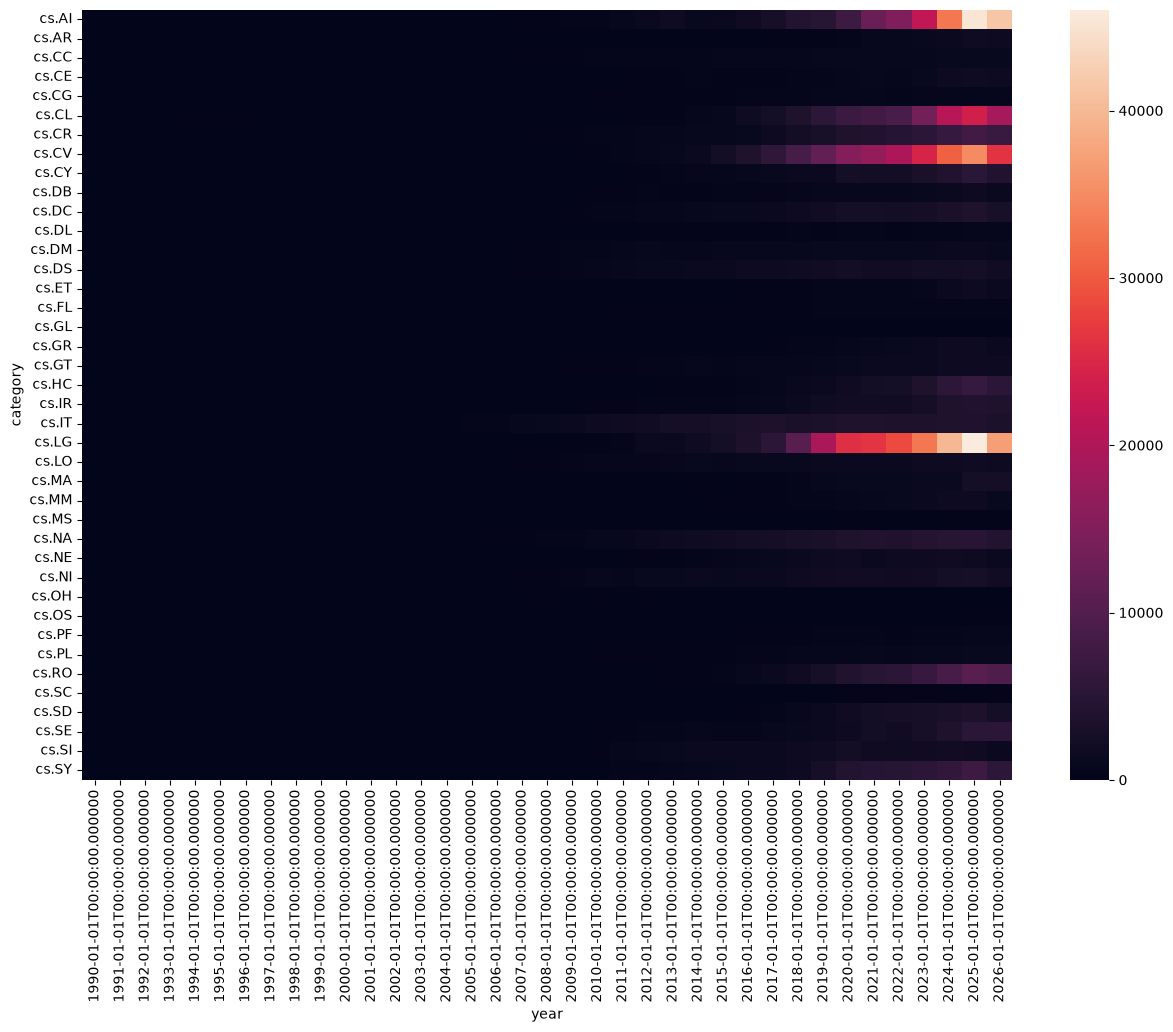

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
sns.heatmap(ydf.fillna(0))

This diagram is still a bit misleading, though. The total volume has increased
year over year. Even if `cs.AI` (Artifical Intelligence), `cs.CV` (Computer
Vision and Pattern Recognition), `cs.CL` (Computation and Language), and 
cs.LG (Machine Learning) appear brightest at
the end, the focus might have been different in other years and is hidden
due to the low volume of articles.

To compensate for this, we have to normalize with respect to the years.

In [39]:
nydf = ydf / ydf.sum()

<Axes: xlabel='year', ylabel='category'>

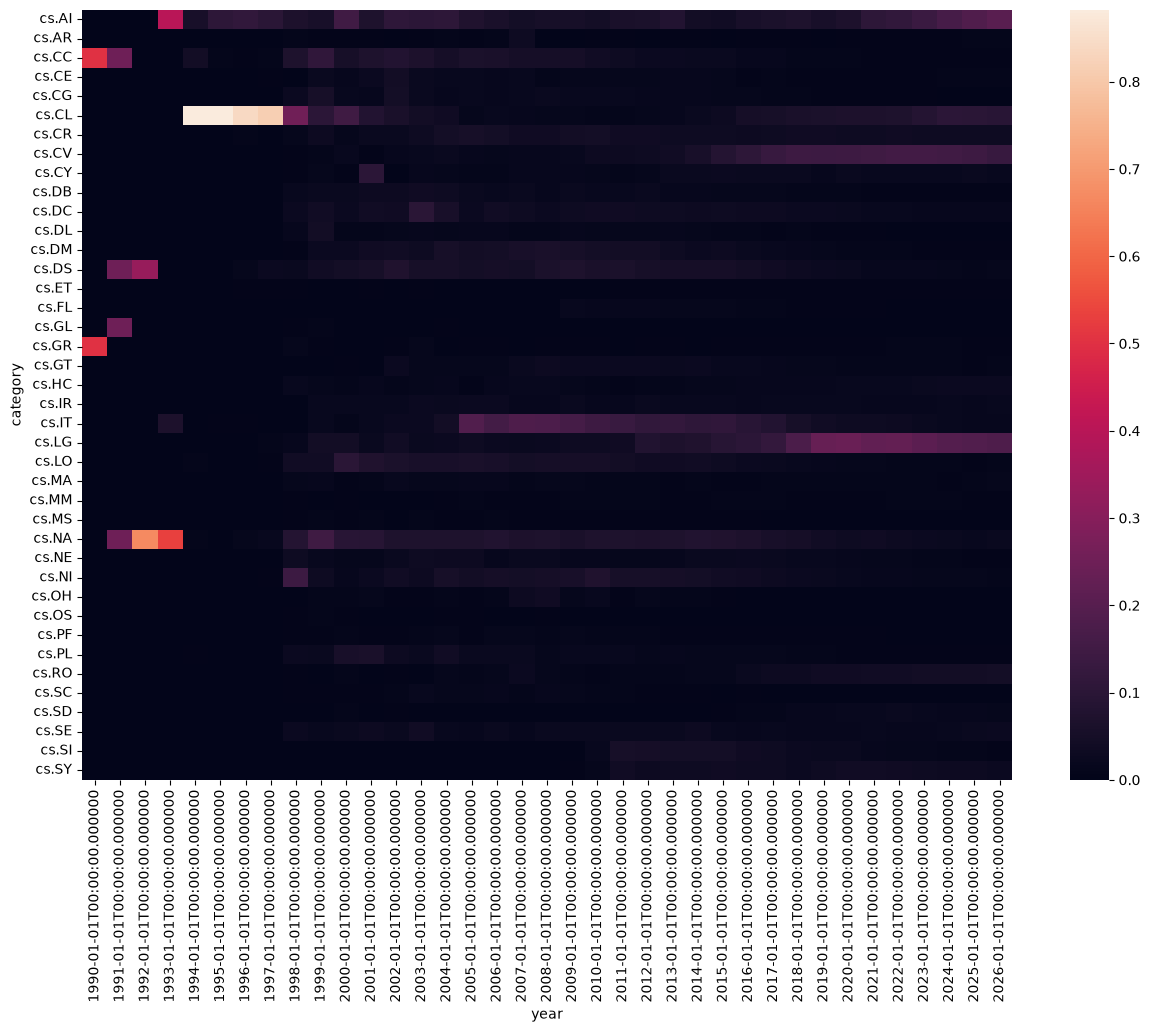

In [40]:
plt.figure(figsize=(15, 10))
sns.heatmap(nydf.fillna(0))

Unfortunately, the outliers in the 1990s are now dominating. Let's fix this in a final step:

<Axes: xlabel='year', ylabel='category'>

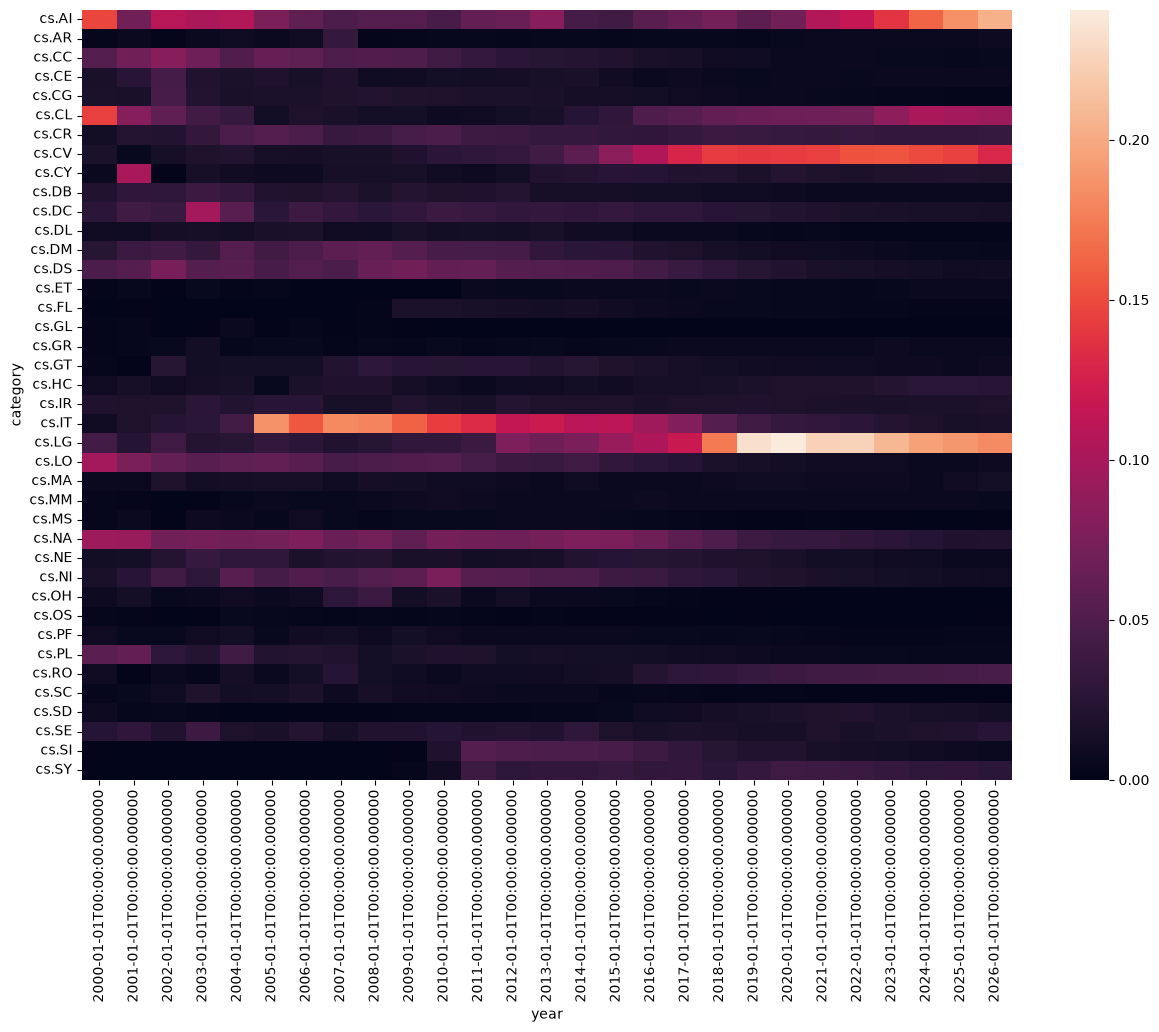

In [41]:
plt.figure(figsize=(15, 10))
sns.heatmap(nydf[[c for c in nydf.columns if c.year > 1999]].fillna(0))

If you want a more quantitative comparison of certain key categories,
you can use a line diagram with the same data. As the `index` will become
the `x` axis, we need to transpose the data and skip the first ten 
entries (from the 1990s):

<Axes: xlabel='year'>

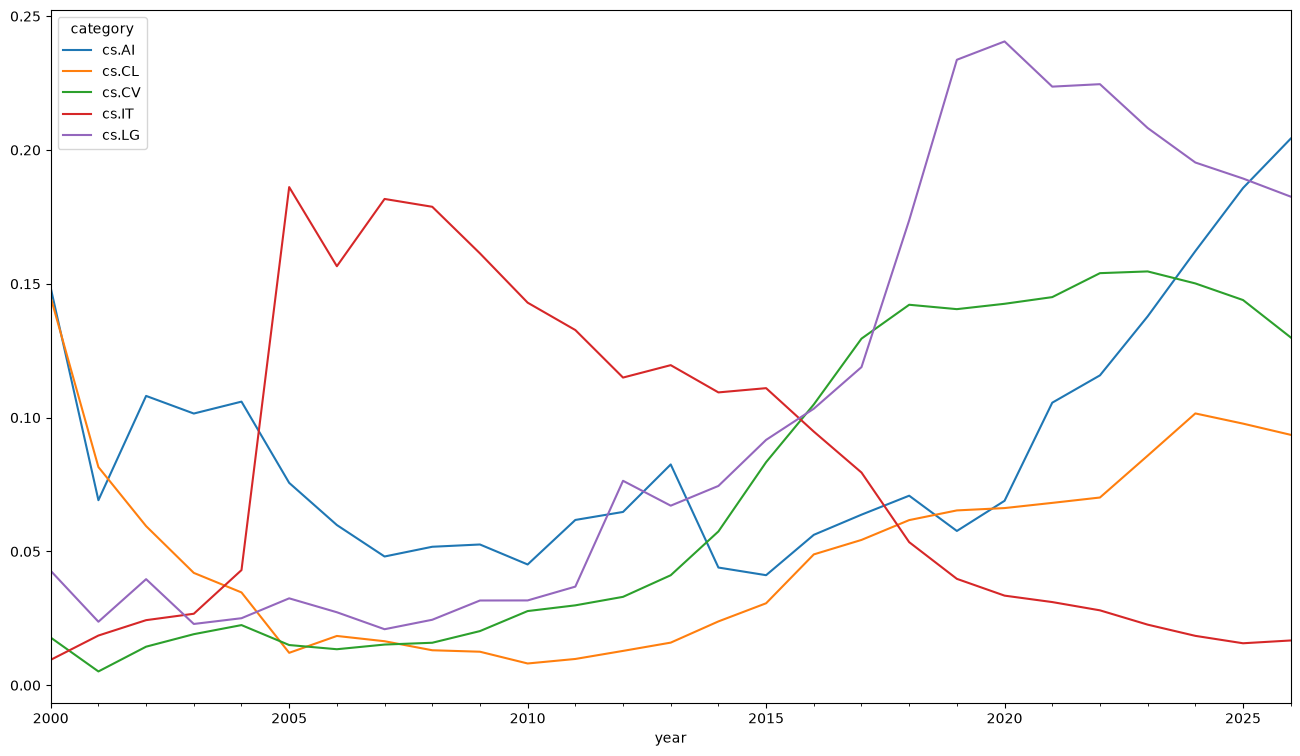

In [42]:
nydf.T[10:][["cs.AI", "cs.CL", "cs.CV", "cs.IT", "cs.LG"]].plot(figsize=(16,9))

As you can now see in this quantitative diagram, `cs.IT` had its high in 2005 to 2015,
dropping sharply afterwards. `cs.LG` became popular after 2016 (because of GPUs and
Deep Learning) whereas `cs.AI` has been steadily increasing since 2019, probably due
to the advances in language models because of the transformer architecture.